In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [5]:
df = pd.read_csv("./data/daily_sales_features.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,daily_sales,day_of_week,day,month,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2011-01-13,20624.64,3,13,1,0,24693.78,32634.47,45418.33,58960.79,33650.078571,28349.940714,17209.499406
1,2011-01-14,47576.90,4,14,1,0,20624.64,40382.85,7534.91,47748.38,31934.388571,26578.962857,17911.945097
2,2011-01-16,7242.06,6,16,1,1,47576.90,28836.59,26789.13,46943.71,32962.110000,29439.105000,18667.908501
3,2011-01-17,29333.02,0,17,1,0,7242.06,15778.20,47304.09,31774.95,29877.177143,28042.885714,21090.393660
4,2011-01-18,95978.05,1,18,1,0,29333.02,24569.07,6199.97,54830.46,31813.580000,26759.237857,20182.895344


In [6]:
features = [
    "day_of_week",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]

X = df[features]
y = df["daily_sales"]

In [7]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [9]:
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
y_pred = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Random Forest Performance")
print("-------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Performance
-------------------------
MAE  : 12,901.44
RMSE : 23,856.31
R²   : 0.2283


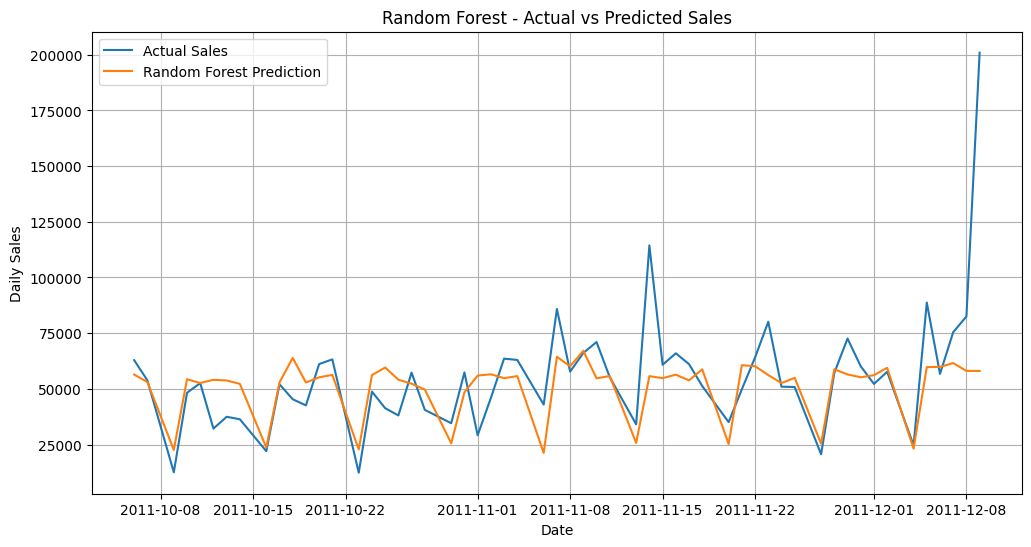

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"].iloc[split_index:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    df["date"].iloc[split_index:],
    y_pred,
    label="Random Forest Prediction"
)

plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Random Forest - Actual vs Predicted Sales")

plt.legend()
plt.grid(True)

plt.show()

In [13]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

            Feature  Importance
2             month    0.120541
3        is_weekend    0.118151
0       day_of_week    0.111991
7            lag_28    0.106772
6            lag_14    0.105617
5             lag_7    0.099121
8    rolling_mean_7    0.086327
9   rolling_mean_14    0.085412
4             lag_1    0.062292
10    rolling_std_7    0.057726
1               day    0.046050


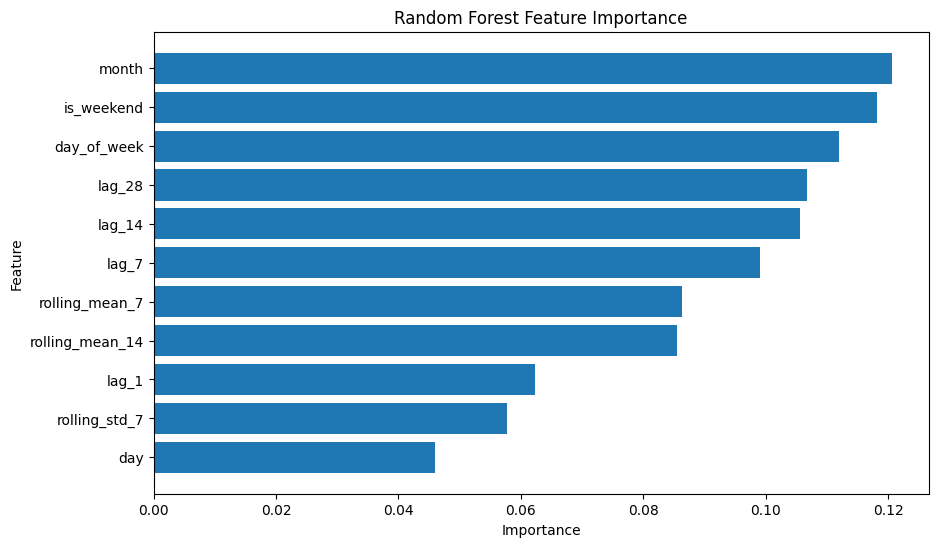

In [14]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [18]:
joblib.dump(
    model,
    "./models/random_forest_sales_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
